# Layer Activation EDA

Exploratory look at the raw GPT-2-small residual-stream activations saved by
`extract_layers.py`.

Each sentence's file (`data/activations/sentence_XXXX.npz`) holds:

- `sentence`: the raw text
- `tokens`: GPT-2 BPE tokens
- `hidden_states`: shape `(13, seq_len, 768)` — `hidden_states[L]` is the residual
  stream *entering* layer `L` (L = 0..11; L=0 is the embedding output), and
  `hidden_states[12]` is the stream *leaving* the final layer. Because the residual
  stream is a running sum, `hidden_states[L]` and `hidden_states[L+1]` are the exact
  pre/post pair for layer `L` — no extra computation needed, and they line up with
  Neuronpedia's `{0..12}-res-jb` SAE checkpoints for gpt2-small.

No truncation and no SAE decomposition here yet — this notebook is just for looking
at what the raw layers look like before deciding how to format them for synthesis.

**Note:** layer 12 previously looked artificially flat here — `output_hidden_states`'s
last entry turned out to be post-final-LayerNorm, not the raw residual stream. Fixed in
`extract_layers.py` (grabbed via a forward hook instead); data below is regenerated.

In [1]:
import importlib.util, subprocess, sys

required = ["numpy", "seaborn", "matplotlib"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

In [2]:
import json
from pathlib import Path
from typing import Optional

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DATA_DIR = Path("data")
ACTIVATIONS_DIR = DATA_DIR / "activations"
index = json.loads((DATA_DIR / "index.json").read_text())
print(f"{len(index['sentences'])} sentences, {index['n_layers']} layers, hidden size {index['hidden_size']}")
index["sentences"][:5]

100 sentences, 13 layers, hidden size 768


[{'id': 0,
  'file': 'sentence_0000.npz',
  'n_tokens': 70,
  'sentence': 'Once upon a time, there was a bald man. He liked to run and play. One day, he went to a park to play. He saw a match on the ground. He picked it up and put it in his pocket. Then he ran around and had fun. Suddenly, he saw a friend and they played together. The end.'},
 {'id': 1,
  'file': 'sentence_0001.npz',
  'n_tokens': 65,
  'sentence': 'Once upon a time, there was a big hall. It was very great and had lots of people in it. A kind teacher came to the hall to teach the people. She had a big book and she read it out loud. The people listened and learned new things. The teacher was happy that she could teach them.'},
 {'id': 2,
  'file': 'sentence_0002.npz',
  'n_tokens': 53,
  'sentence': 'Once upon a time, there was a lady. She was very high up in the sky. She could see everything from up there. One day, she did a big jump and everyone was happy. They began to applaud her. The lady felt very happy too!'},
 {

In [3]:
def load_sentence(sentence_id: int) -> dict:
    entry = index["sentences"][sentence_id]
    npz = np.load(ACTIVATIONS_DIR / entry["file"], allow_pickle=True)
    return {
        "sentence": str(npz["sentence"]),
        "tokens": list(npz["tokens"]),
        "hidden_states": npz["hidden_states"],  # (n_layers, seq_len, 768)
    }


def clean_token(tok: str) -> str:
    """GPT-2 byte-level BPE encodes a leading space as the character Ġ and a
    newline as Ċ -- swap those back to something readable for axis labels
    (display only, does not change the underlying data)."""
    return tok.replace("Ġ", " ").replace("Ċ", "⏎")


def clean_tokens(tokens):
    return [clean_token(t) for t in tokens]

## Heatmap helper

Changes from the original sketch:

1. **Color scale defaults to a [1, 99] percentile clip instead of true min/max.** GPT-2's
   residual stream has a handful of "massive activation" outlier dimensions (e.g. dim 447
   from roughly layer 3 on) that run 50-100x larger than everything else, on every token.
   `vmin=data.min(), vmax=data.max()` lets those few dims set the whole scale, collapsing
   the other ~760 (where the token-dependent signal actually lives) into one solid color —
   pass `clip_percentile=None` to see that. Clipping recovers visible column-banding,
   itself evidence a handful of dims dominate regardless of token, part of why we're
   planning to move to SAE features rather than raw dims for the actual synthesis input.
2. **`cmap="Blues"`, not `"Blues_r"`.** The `_r` suffix reverses a colormap. Plain `Blues`
   maps low->near-white, high->dark blue (blue = high, matching intuition); `Blues_r` is
   the opposite. Pass `cmap="Blues_r"` explicitly if you want it inverted.
3. **The color scale is *not* absolute or comparable across panels by default.** The
   [1,99] percentile is computed fresh from whatever `data_2d` you pass in, per call.
   Residual-stream values are unbounded, and their scale genuinely shifts a lot with
   depth (median `|x|` was ~0.06 at L0, ~1.15 at L6, ~2.0 at L9, back down to ~0.26 at L12
   in earlier EDA) — so "more blue" in one panel vs. another is only meaningful *within*
   that panel unless you explicitly pass a shared `vmin`/`vmax` (the grid cells below do
   this: they z-score each panel, then share one scale across the whole grid, so color
   reflects "how unusual for this layer," comparably across panels — see those cells).

Axis labels are off by default for both axes (768 columns and often-long token sequences
both overlap into unreadable clutter) — pass `token_labels=` explicitly to turn on row
labels (use `clean_tokens(...)` to get readable text instead of raw BPE tokens).

In [4]:
def plot_layer_heatmap(data_2d: np.ndarray, title: str, token_labels=None, ax=None,
                        clip_percentile: Optional[float] = 1.0, cmap="Blues",
                        vmin: Optional[float] = None, vmax: Optional[float] = None,
                        cbar: bool = False, cbar_label: Optional[str] = None,
                        use_power_norm: bool = True, xticklabels=False):
    """data_2d: (seq_len, n_cols) slice -- n_cols is 768 for a raw layer, or 1 for a
    single cosine-similarity column (see the cosine-similarity grid below, which reuses
    this same function rather than a bespoke one).

    clip_percentile: color scale is set from the [p, 100-p] percentiles of THIS panel's
    own data (set to None to use true min/max instead). Ignored if vmin/vmax are given.
    vmin/vmax: pass explicitly to share one color scale across multiple panels (see the
    grid cells below) instead of each panel auto-scaling to its own range.
    token_labels: row (token) labels; omit/None to leave the y-axis blank (default, since
    most sequences are too long to label legibly) -- pass clean_tokens(tokens) to show them.
    cbar/cbar_label: show a colorbar (off by default -- the 768-wide raw grids don't need
    one; the cosine-similarity heatmap below turns it on, since there its axis has a
    real bounded meaning worth reading off).
    use_power_norm: gamma=0.5 PowerNorm, good for raw activations dominated by a few huge
    outliers. Cosine similarity has no such outliers -- pass False for a plain linear scale.
    xticklabels: False by default (768 raw dims aren't informative to label); pass a list
    of column labels for a plot with a small, meaningful number of columns instead.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(20, max(3, 0.3 * data_2d.shape[0])))

    if vmin is None or vmax is None:
        if clip_percentile is None:
            vmin, vmax = data_2d.min(), data_2d.max()
        else:
            vmin = np.percentile(data_2d, clip_percentile)
            vmax = np.percentile(data_2d, 100 - clip_percentile)
    norm = mcolors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax) if use_power_norm else None
    sns.heatmap(
        data_2d,
        ax=ax,
        cmap=cmap,
        xticklabels=xticklabels,
        yticklabels=token_labels if token_labels is not None else False,
        cbar=cbar,
        cbar_kws={"label": cbar_label} if cbar_label else {},
        norm=norm,
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
    )
    ax.set_title(title, fontsize=18, fontweight="bold", pad=12, loc="left")
    if own_fig:
        plt.tight_layout()
        plt.show()


from matplotlib.colors import LinearSegmentedColormap

REDGREEN = LinearSegmentedColormap.from_list("redgreen", ["#f4cccc", "#d9ead3"])

## Single sentence, single layer

Change `SENTENCE_ID` / `LAYER` and rerun — this is the main cell to "play with."

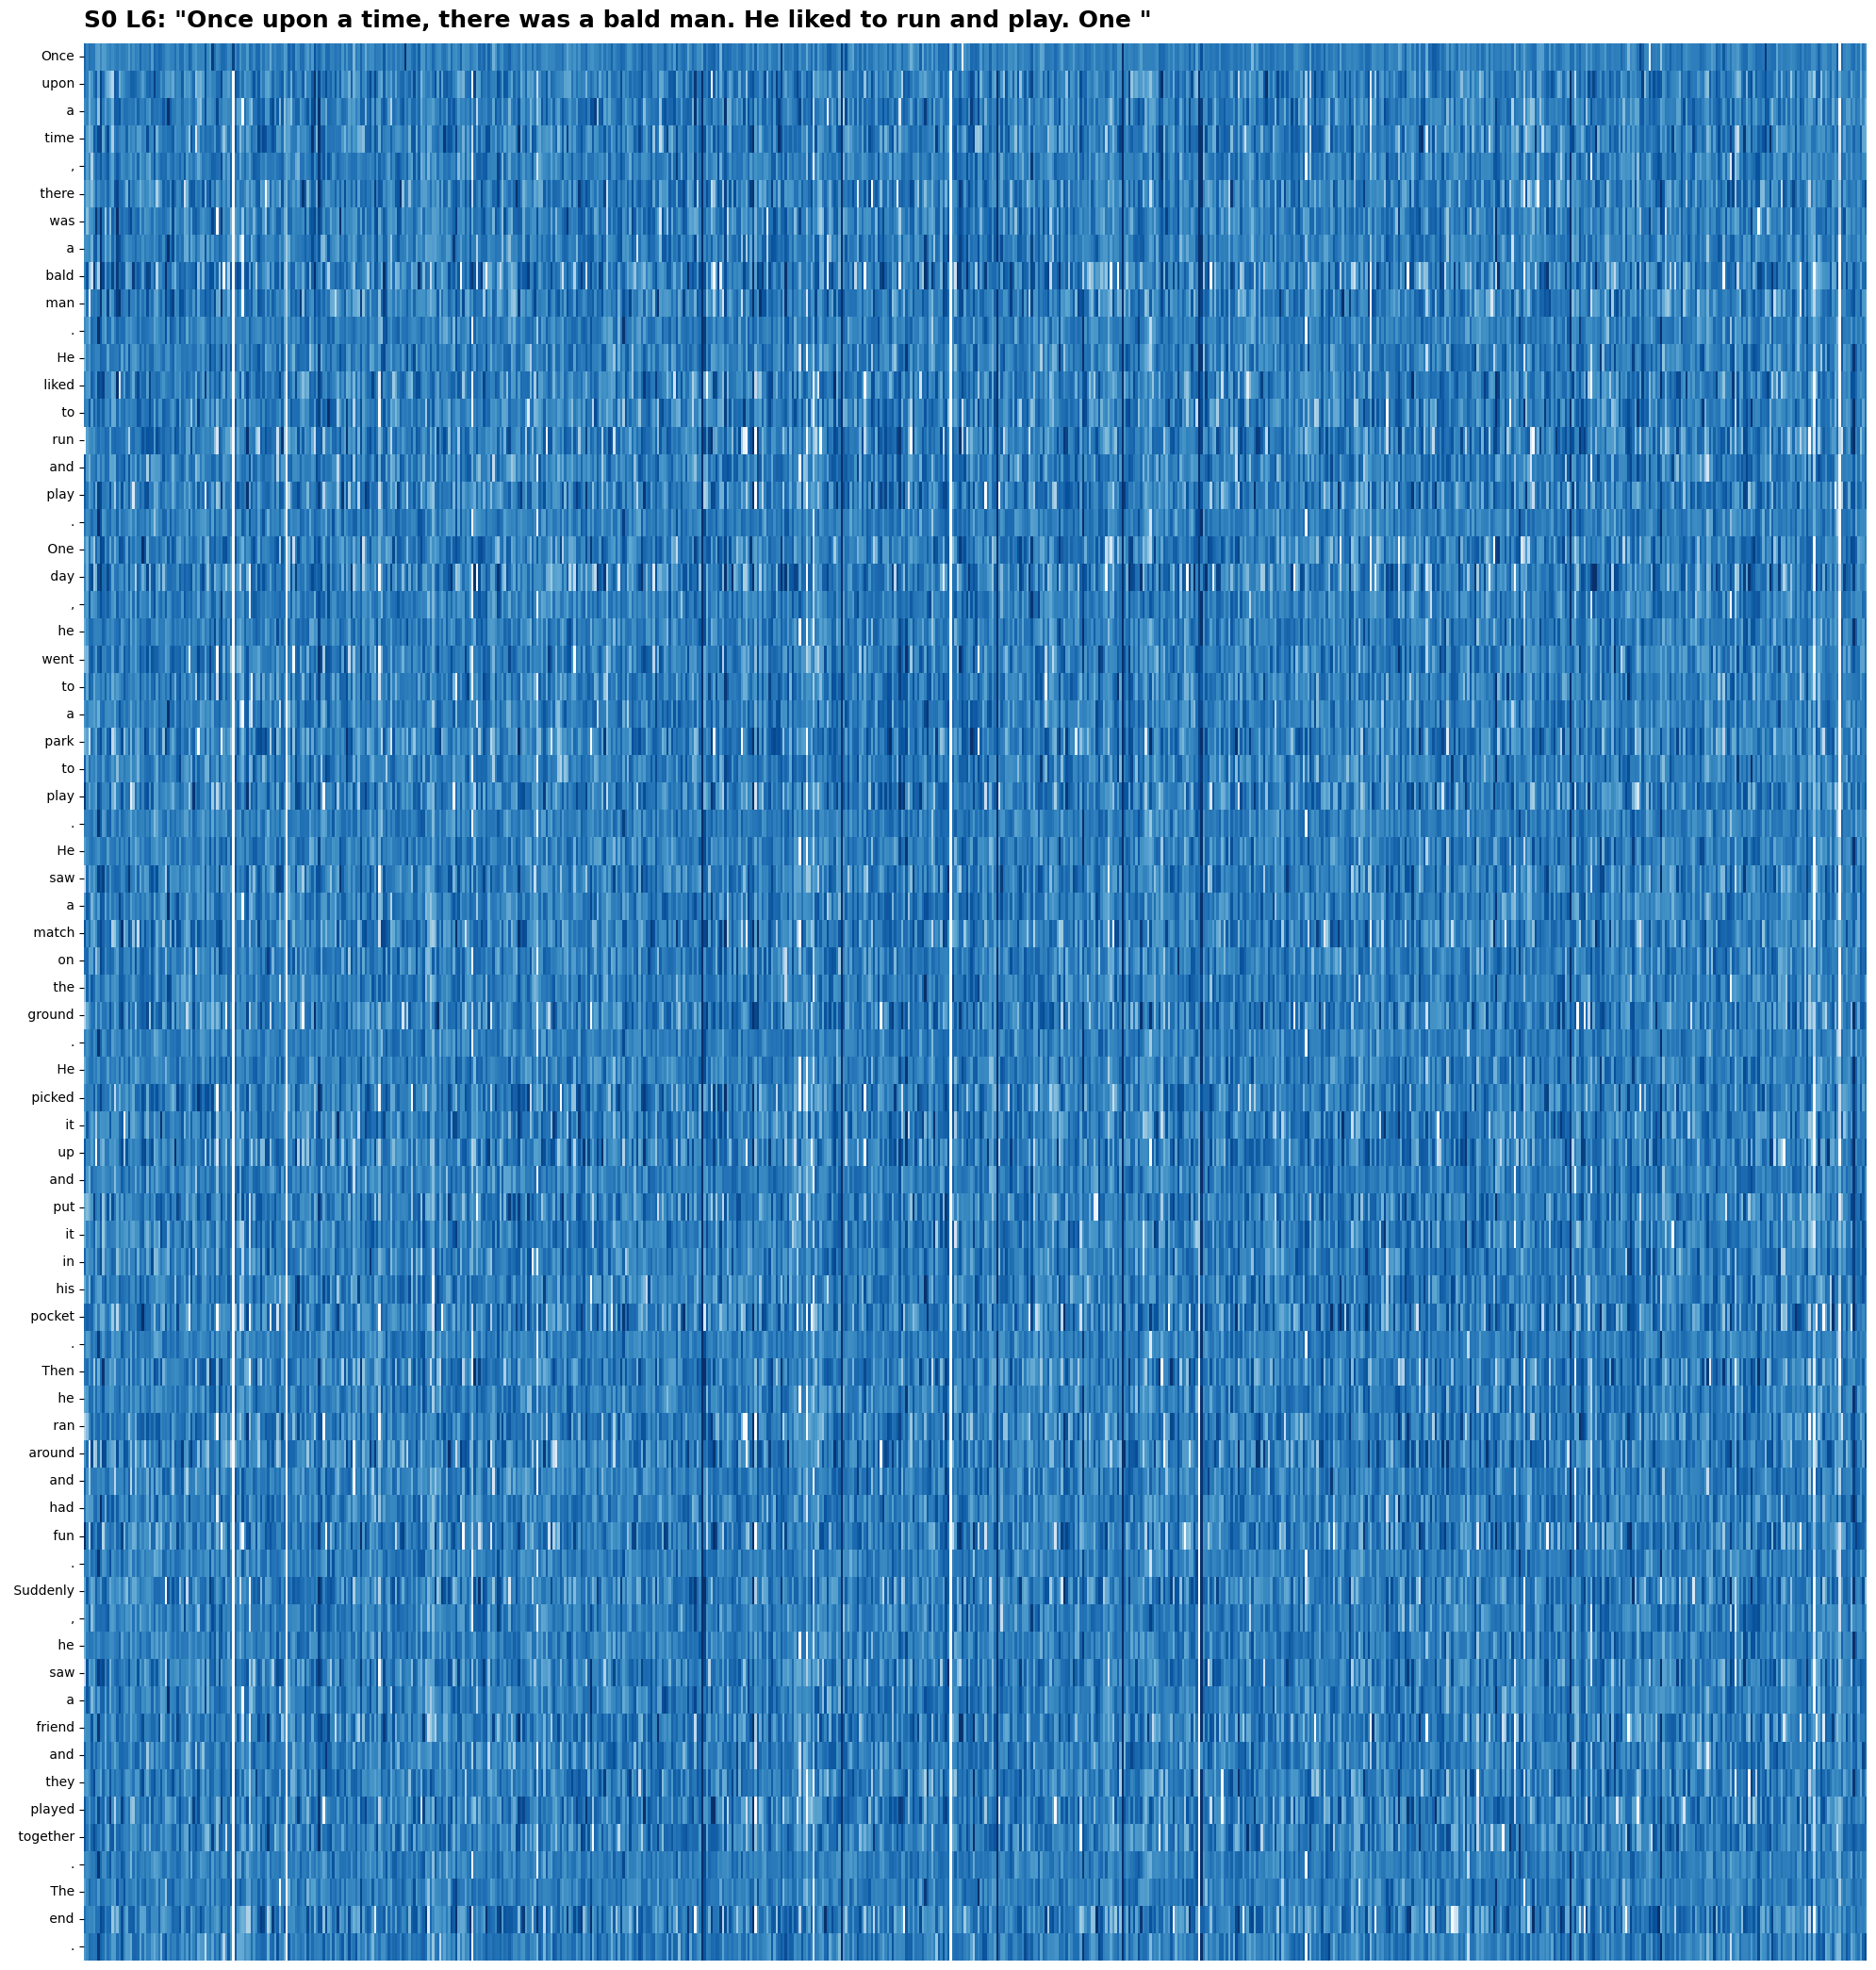

In [5]:
SENTENCE_ID = 0
LAYER = 6

ex = load_sentence(SENTENCE_ID)
plot_layer_heatmap(
    ex["hidden_states"][LAYER],
    title=f'S{SENTENCE_ID} L{LAYER}: "{ex["sentence"][:70]}"',
    token_labels=clean_tokens(ex["tokens"]),
)

## Grid across layers, one sentence

See how the same sentence's representation shifts with depth. All panels share one
color scale — the [1,99] percentile of the *raw* values pooled across the shown
layers (no per-layer standardizing) — so color reflects real relative magnitude,
not "how unusual for this layer." Tradeoff to know going in: since typical magnitude
genuinely grows a lot with depth (median `|x|` ~0.06 at L0 vs. ~2.0 at L9 in this
sentence), the low-magnitude layers (especially L0) will look almost flat under a
shared raw scale — that's the real gap being shown honestly, not an artifact. Swap
back to z-scoring first (see previous version / the single-panel cell above) if you
want each layer's own relative structure instead of the true cross-layer magnitude.

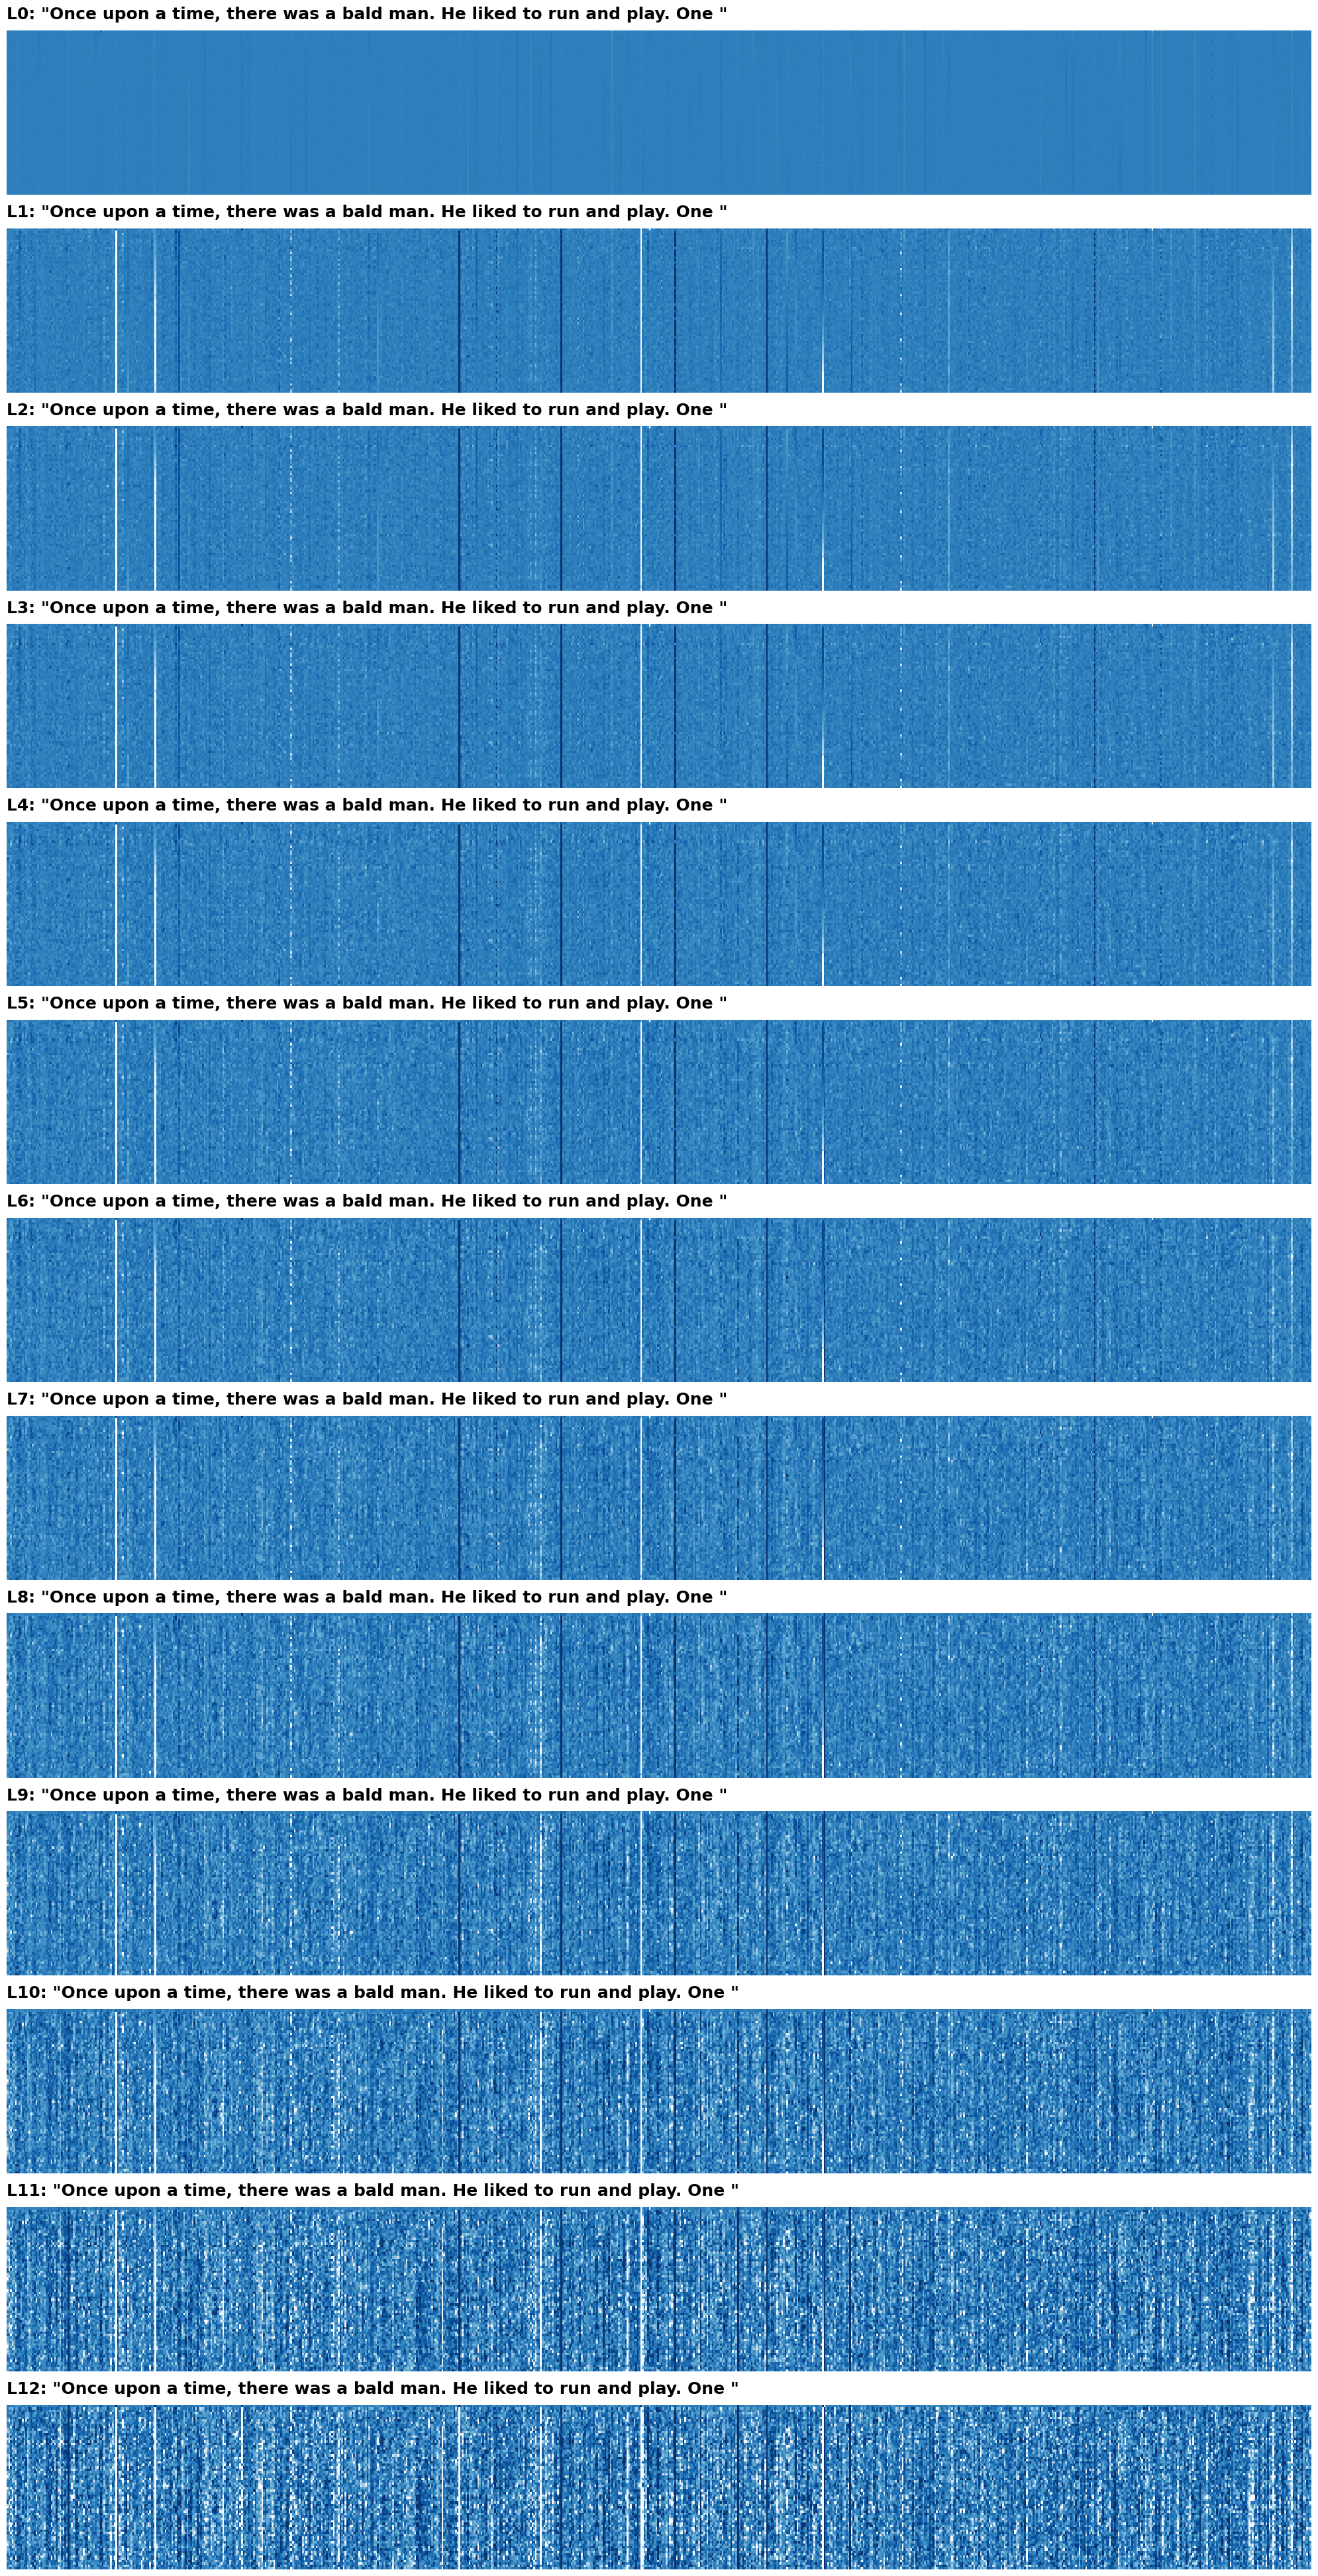

In [6]:
ex = load_sentence(0)
layers_to_show = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # full run, gets the whole trend
sentence_preview = ex["sentence"][:70]

# shared scale from RAW (non-standardized) values pooled across the shown layers
pooled = np.concatenate([ex["hidden_states"][L].ravel() for L in layers_to_show])
shared_vmin, shared_vmax = np.percentile(pooled, 1), np.percentile(pooled, 99)

fig, axes = plt.subplots(len(layers_to_show), 1, figsize=(20, 3 * len(layers_to_show)))
for ax, L in zip(axes, layers_to_show):
    plot_layer_heatmap(
        ex["hidden_states"][L], title=f'L{L}: "{sentence_preview}"', ax=ax,
        vmin=shared_vmin, vmax=shared_vmax,
    )
plt.tight_layout()
plt.show()

In [7]:
def layer_to_layer_cosine_sim(hidden_states: np.ndarray) -> np.ndarray:
    """hidden_states: (n_layers, seq_len, 768) -> (n_layers-1, seq_len), the
    per-token cosine similarity between each consecutive pair of layers. Row k is
    the transition INTO layer k+1 (i.e. L{k} -> L{k+1}).
    """
    n_layers = hidden_states.shape[0]
    sims = np.zeros((n_layers - 1, hidden_states.shape[1]))
    for k in range(n_layers - 1):
        a, b = hidden_states[k], hidden_states[k + 1]
        num = (a * b).sum(axis=-1)
        denom = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
        sims[k] = num / denom
    return sims

## Grid across layers, one sentence — difference

Same grid, same `plot_layer_heatmap`, `[seq_len, 768]` per panel -- the raw difference
`hidden_states[L] - hidden_states[L-1]`, in `cmap=REDGREEN`, shared-scale percentile
clip pooled across the shown transitions. Each panel's title also carries that
transition's mean per-token cosine similarity, from `layer_to_layer_cosine_sim`.

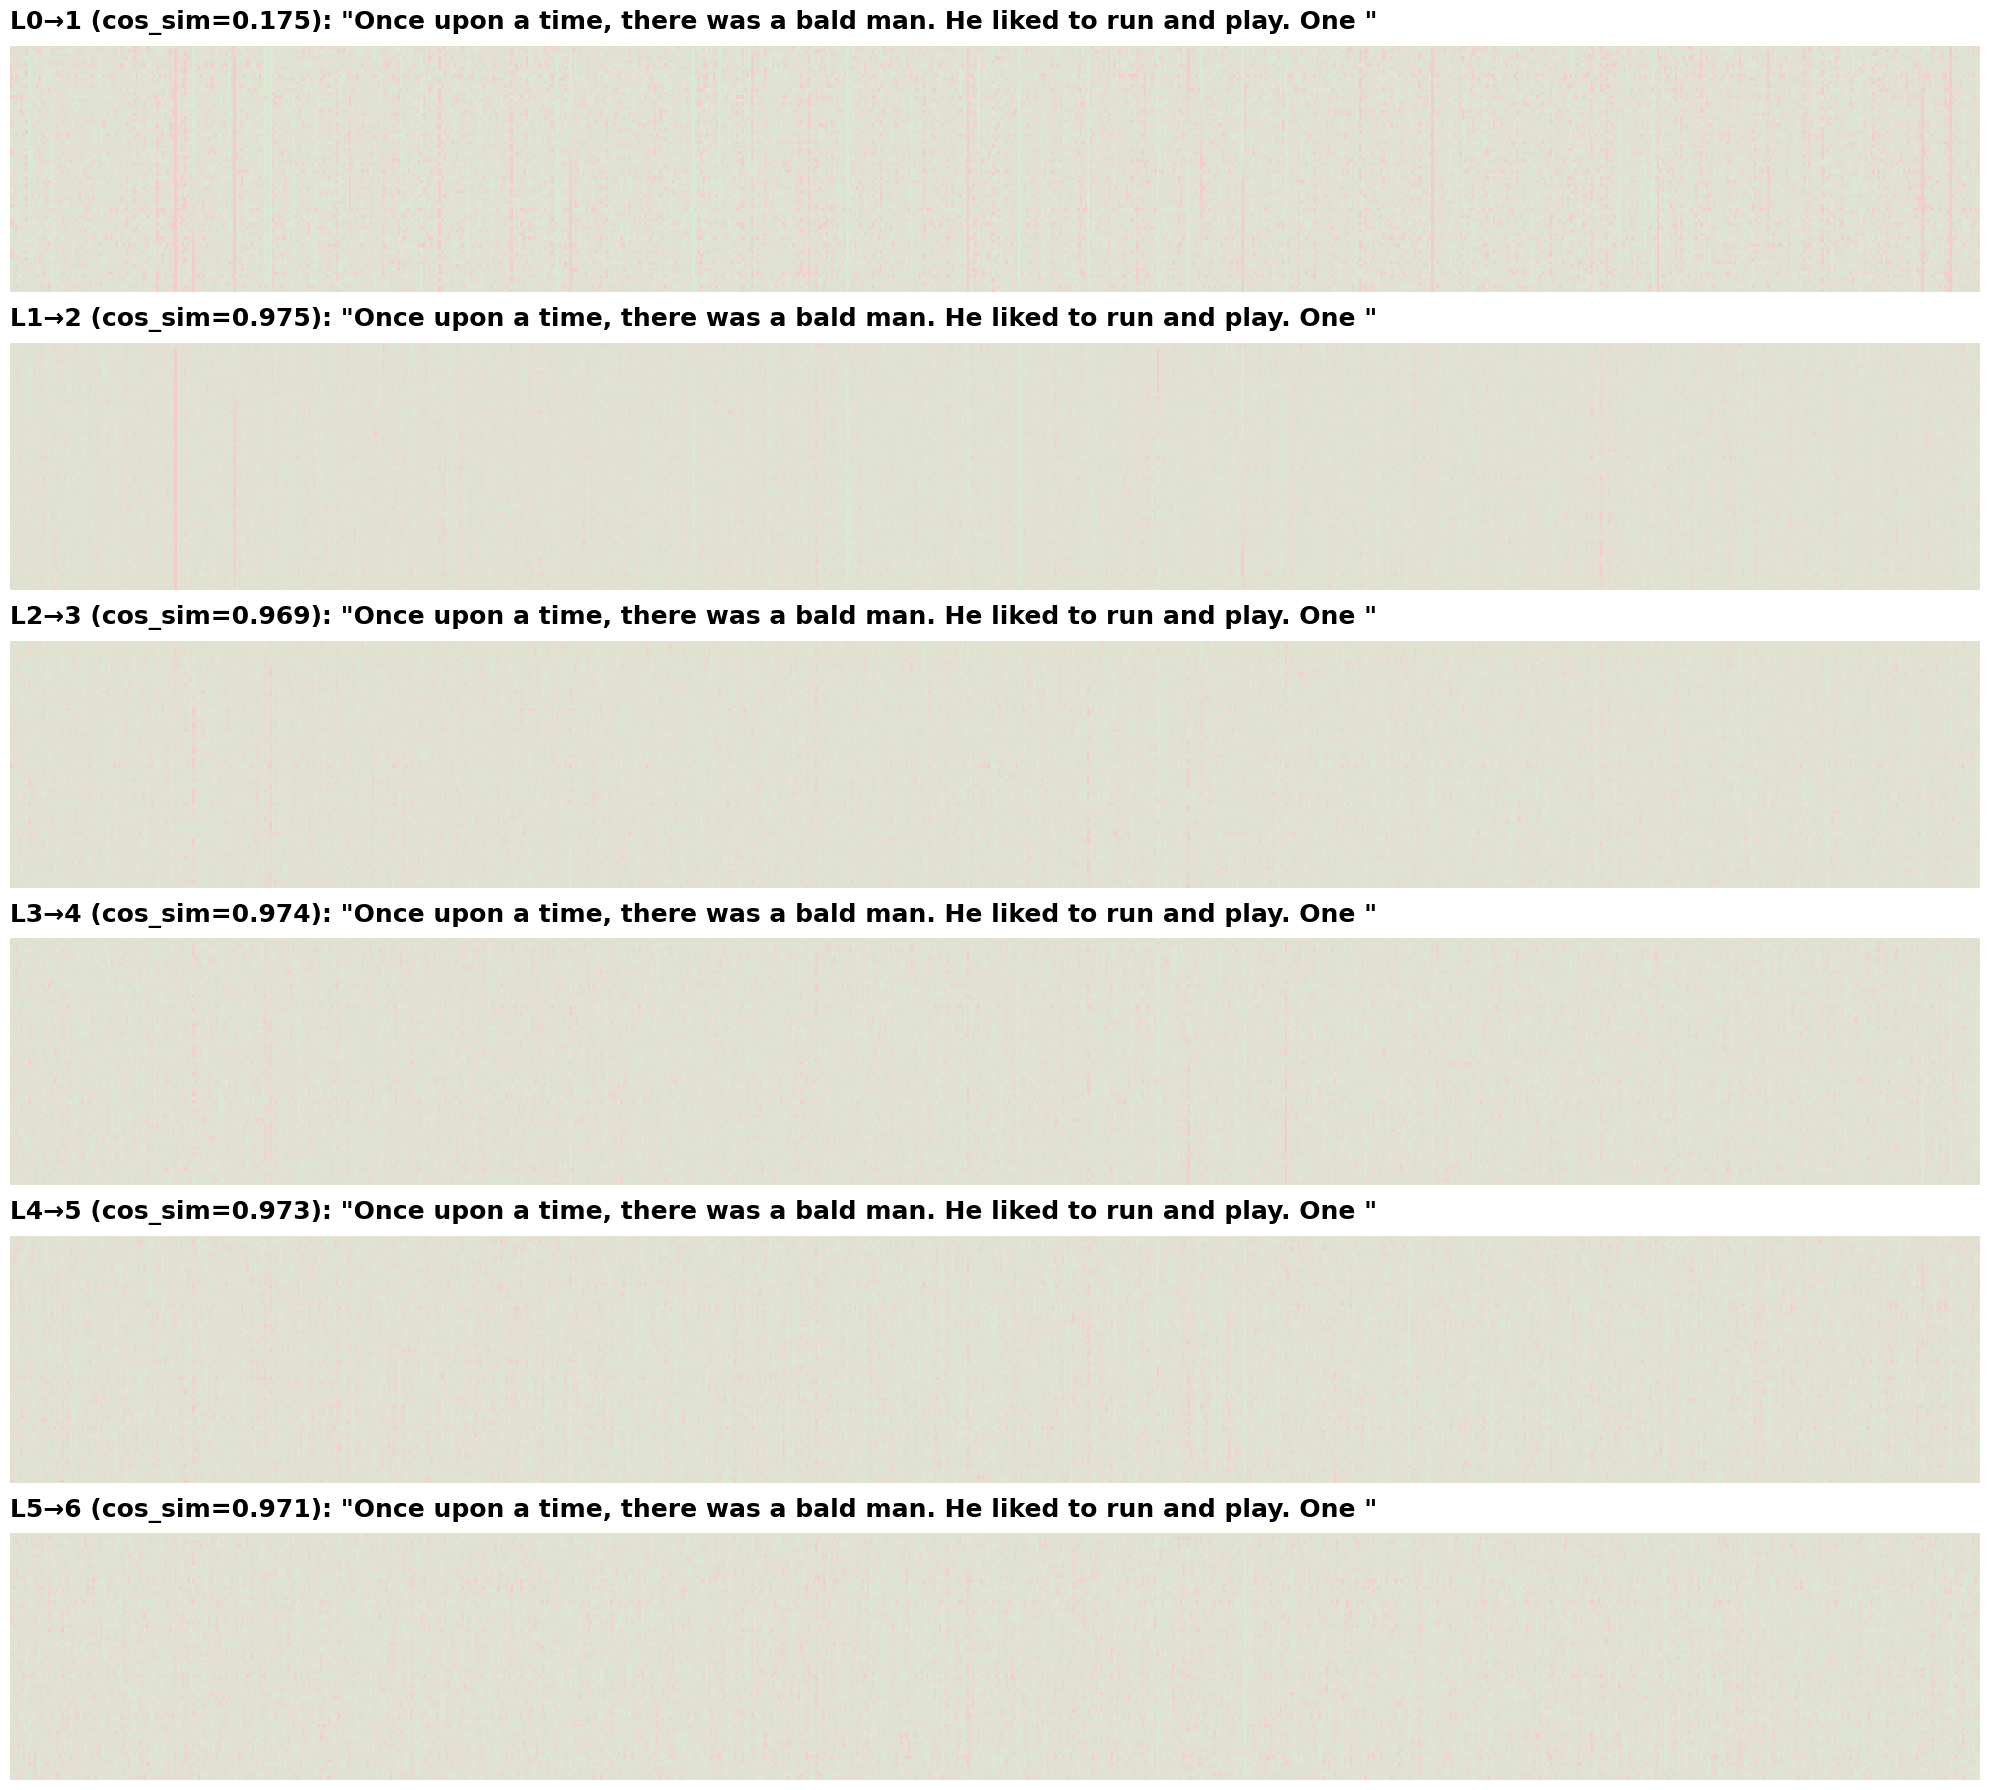

In [8]:
ex = load_sentence(0)
layers_to_show = [1, 2, 3, 4, 5, 6]
sentence_preview = ex["sentence"][:70]

diffs = {L: ex["hidden_states"][L] - ex["hidden_states"][L - 1] for L in layers_to_show}
pooled = np.concatenate([d.ravel() for d in diffs.values()])
shared_vmin, shared_vmax = np.percentile(pooled, 1), np.percentile(pooled, 99)
sims = layer_to_layer_cosine_sim(ex["hidden_states"])  # row k = cos_sim for L{k}->L{k+1}

fig, axes = plt.subplots(len(layers_to_show), 1, figsize=(20, 3 * len(layers_to_show)))
for ax, L in zip(axes, layers_to_show):
    cos_sim = sims[L - 1].mean()
    plot_layer_heatmap(
        diffs[L], title=f'L{L - 1}\u2192{L} (cos_sim={cos_sim:.3f}): "{sentence_preview}"', ax=ax,
        cmap=REDGREEN, vmin=shared_vmin, vmax=shared_vmax,
    )
plt.tight_layout()
plt.show()

## Grid across sentences, one layer

See how different sentences look at the same depth. Same standardize-then-share-scale
treatment, this time across sentences at a fixed layer.

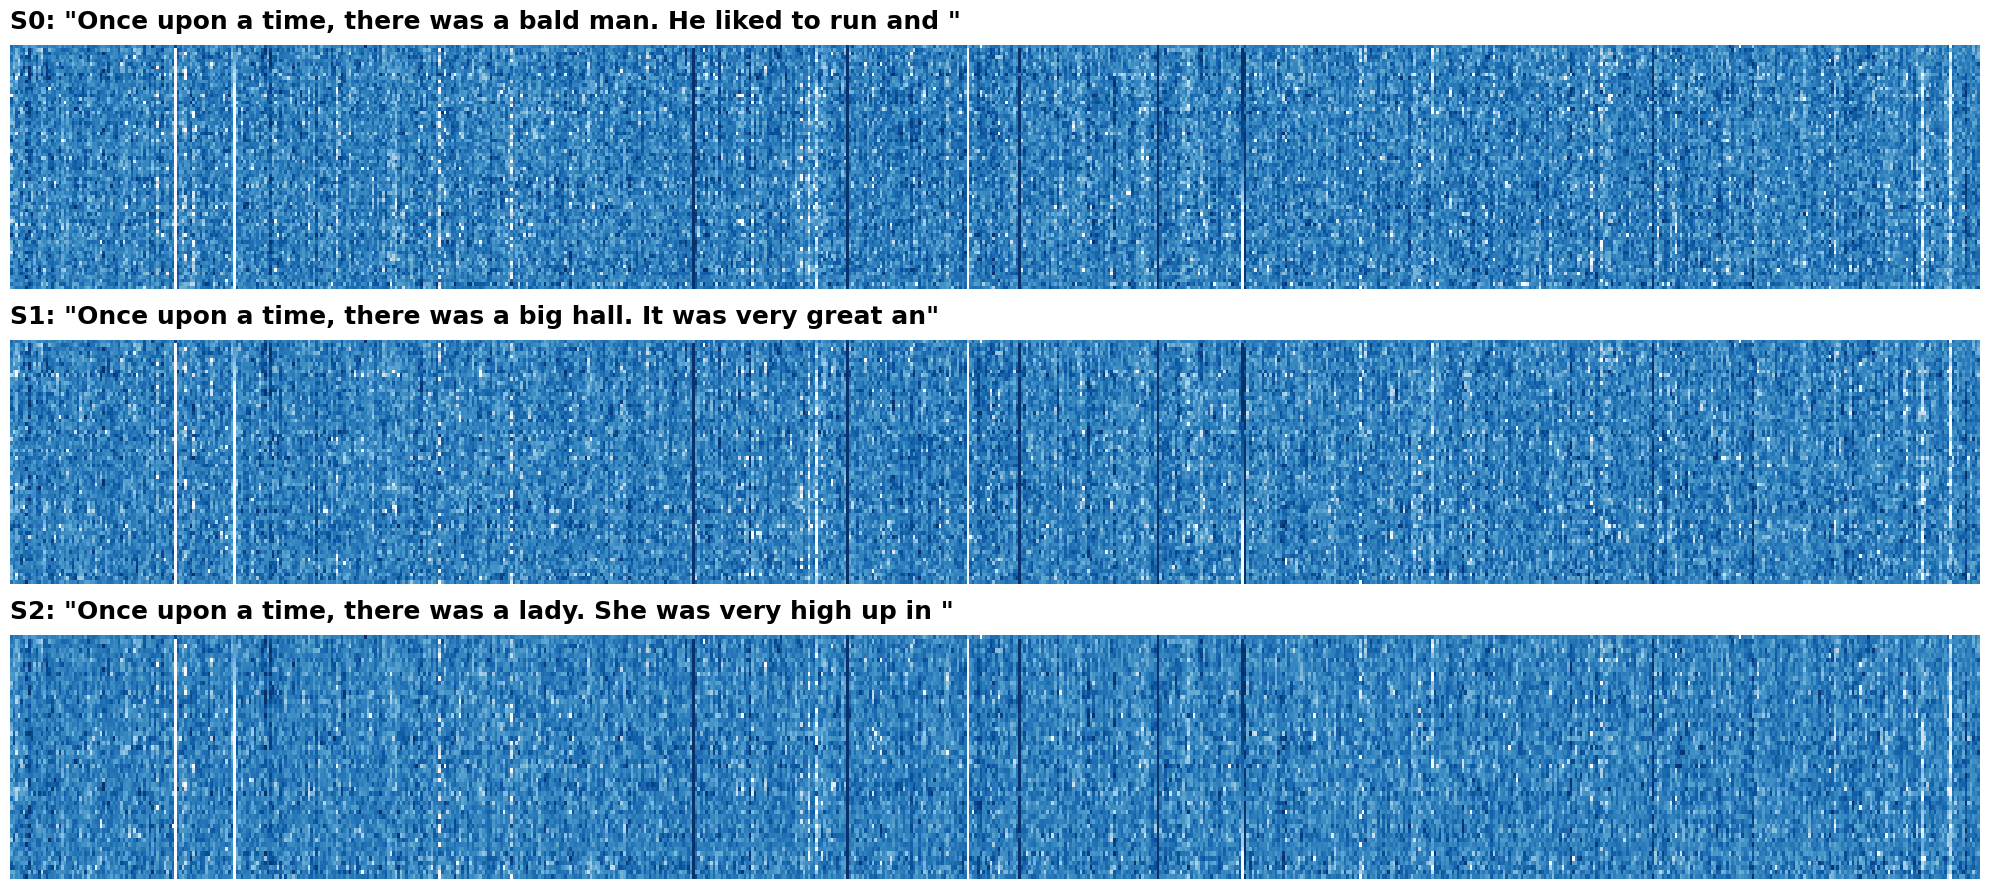

In [9]:
LAYER = 6
sentence_ids = [0, 1, 2]
exs = [load_sentence(sid) for sid in sentence_ids]

zs = []
for ex in exs:
    d = ex["hidden_states"][LAYER]
    zs.append((d - d.mean()) / d.std())
pooled = np.concatenate([z.ravel() for z in zs])
shared_vmin, shared_vmax = np.percentile(pooled, 1), np.percentile(pooled, 99)

fig, axes = plt.subplots(len(sentence_ids), 1, figsize=(20, 3 * len(sentence_ids)))
for ax, sid, ex, z in zip(axes, sentence_ids, exs, zs):
    plot_layer_heatmap(
        z, title=f'S{sid}: "{ex["sentence"][:60]}"', ax=ax, vmin=shared_vmin, vmax=shared_vmax,
    )
plt.tight_layout()
plt.show()

## Actual vs predicted: sentence-level and token-level programs

The two programs behind the Manhattan-distance sweep (`manhattan_trend.py`), fit here
on the 50 train sentences and shown against a genuinely held-out test sentence:

- **token-level**: exact literal-token-identity lookup -- `mean(train activations)` for
  every train instance of that exact token string, falling back to the global train mean
  for tokens never seen in train. No context, no generalization beyond identity.
- **sentence-level**: one `Ridge` regression, `primitives -> full 768-dim vector`, using
  the full 571-word train lexicon (not the truncated top-40 -- see the lexicon-widening
  discussion). Genuinely generalizes: unlike the lookup table, it can produce a prediction
  for a token it never saw in train.

All three panels share one color scale (percentile-clipped, pooled across all three) so
they're visually comparable -- same convention as the raw grids above.

In [10]:
import sys
from collections import defaultdict

sys.path.insert(0, ".")
from primitive_library import PrimitiveBuilder, build_lexicon
from sklearn.linear_model import Ridge

split = json.loads(Path("data/split.json").read_text())
lexicon = build_lexicon(index, split["train"], top_k=100000)  # full vocab, matches manhattan_trend.py
builder = PrimitiveBuilder(lexicon)
print(f"lexicon size: {len(lexicon)}, primitive dims: {builder.n_dims}")


def gather(sentence_ids, layer):
    toks_all, Xs, Ys = [], [], []
    for sid in sentence_ids:
        ex = load_sentence(sid)
        toks_all.extend(ex["tokens"])
        Xs.append(builder(ex["tokens"], ex["sentence"]))
        Ys.append(ex["hidden_states"][layer])
    return toks_all, np.concatenate(Xs), np.concatenate(Ys)


def fit_programs(layer):
    train_tokens, train_X, train_Y = gather(split["train"], layer)
    dim_std = train_Y.std(axis=0)  # train-derived, same convention as the Manhattan sweep

    buckets = defaultdict(list)
    for tok, row in zip(train_tokens, train_Y):
        buckets[tok].append(row)
    token_means = {tok: np.mean(rows, axis=0) for tok, rows in buckets.items()}
    global_mean = train_Y.mean(axis=0)

    def token_level_program(tokens):
        return np.array([token_means.get(t, global_mean) for t in tokens])

    sentence_model = Ridge(alpha=1.0).fit(train_X, train_Y)

    def sentence_level_program(tokens, sentence):
        return sentence_model.predict(builder(tokens, sentence))

    return token_level_program, sentence_level_program, dim_std

lexicon size: 571, primitive dims: 594


/Users/amirihayes/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


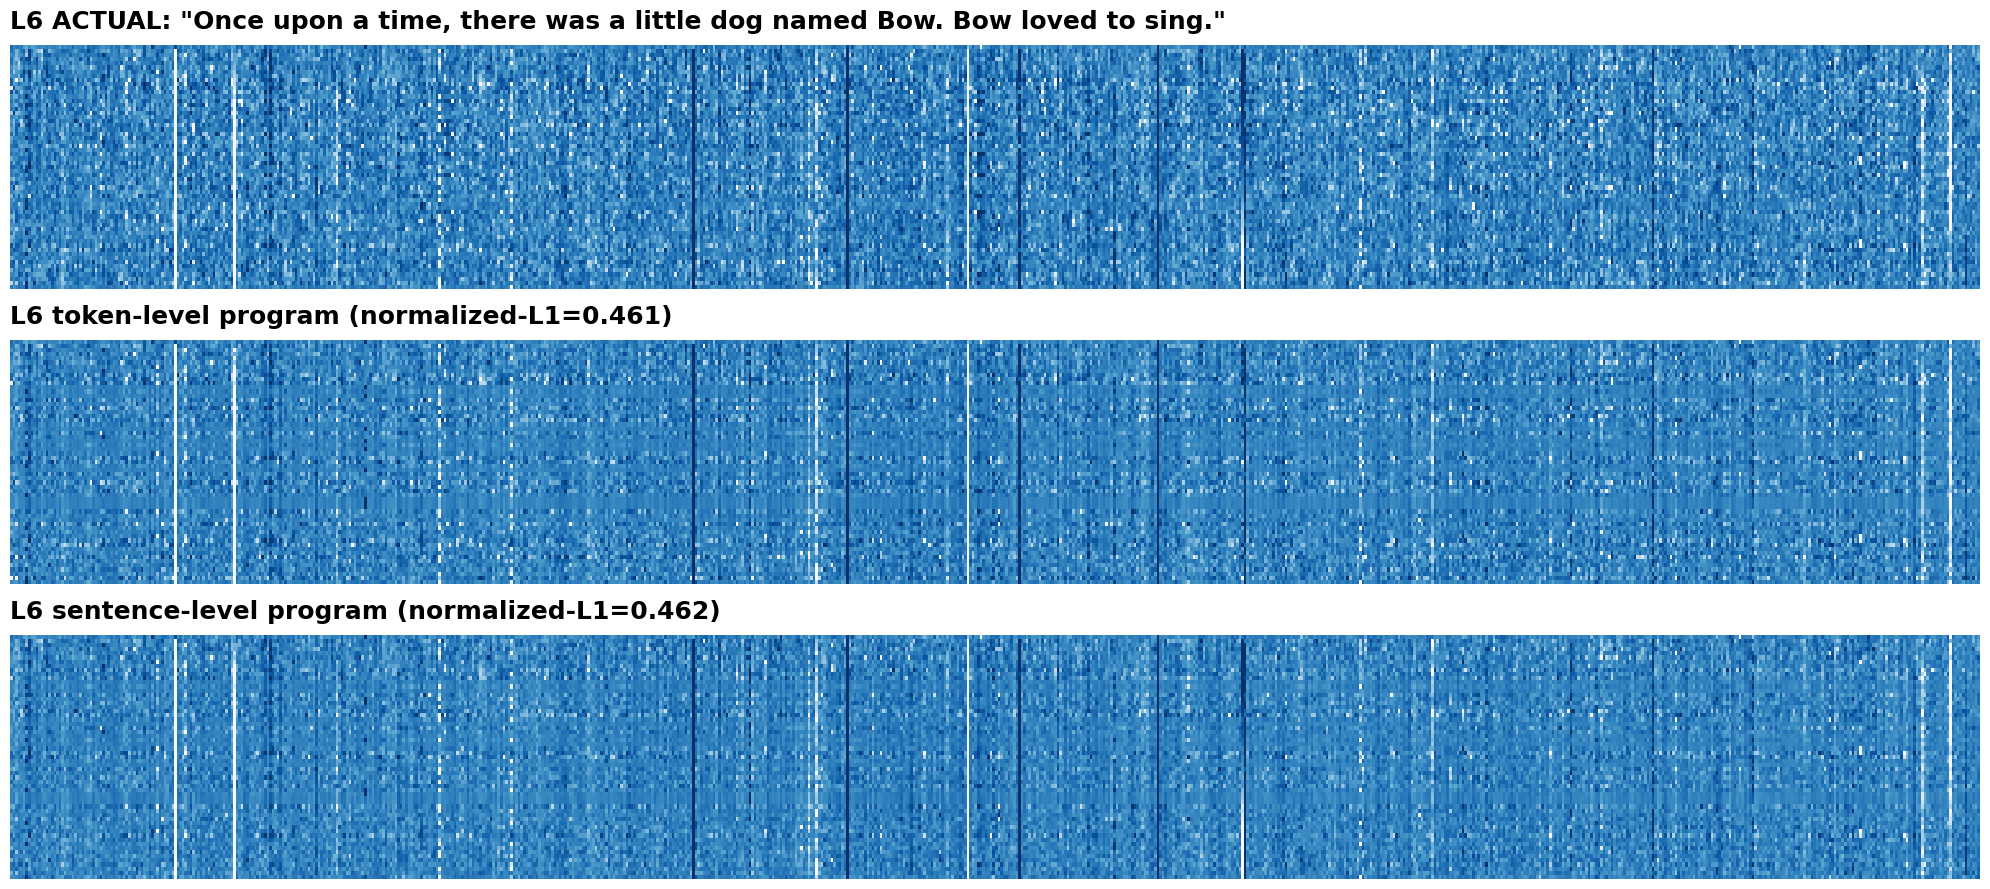

In [11]:
LAYER = 6
TEST_SENTENCE_ID = split["test"][0]  # genuinely held out -- neither program saw this sentence

token_level_program, sentence_level_program, dim_std = fit_programs(LAYER)

ex = load_sentence(TEST_SENTENCE_ID)
actual = ex["hidden_states"][LAYER]
token_pred = token_level_program(ex["tokens"])
sentence_pred = sentence_level_program(ex["tokens"], ex["sentence"])
sentence_preview = ex["sentence"][:70]

token_score = (np.abs(actual - token_pred) / dim_std).mean()
sentence_score = (np.abs(actual - sentence_pred) / dim_std).mean()

pooled = np.concatenate([actual.ravel(), token_pred.ravel(), sentence_pred.ravel()])
shared_vmin, shared_vmax = np.percentile(pooled, 1), np.percentile(pooled, 99)

panels = [
    (actual, f'L{LAYER} ACTUAL: "{sentence_preview}"'),
    (token_pred, f"L{LAYER} token-level program (normalized-L1={token_score:.3f})"),
    (sentence_pred, f"L{LAYER} sentence-level program (normalized-L1={sentence_score:.3f})"),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(20, 3 * len(panels)))
for ax, (data, title) in zip(axes, panels):
    plot_layer_heatmap(data, title=title, ax=ax, vmin=shared_vmin, vmax=shared_vmax)
plt.tight_layout()
plt.show()

## Next steps (not yet in this notebook)

- Row-level (token) study: subsample ~20 (sentence, position) pairs from this same full-length data rather than truncating every sentence to 20 tokens (truncating the tail is lossless under causal masking, but truncating every example biases the sample toward sentence-openings).
- Axis-level (SAE feature) study: run each layer's activations through the matching `{L}-res-jb` SAE encoder (via `sae_lens`) to get the sparse, Neuronpedia-described feature activations these dense heatmaps are standing in for.